In [1]:
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from torchvision import (
    datasets,
    transforms
)

from torchvision.models import (
    efficientnet_b0
)

from torch.utils.data import (
    DataLoader
)

In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

MODEL_PATH = "../models/modelo_efficientnet.pth"
DATASET_PATH = "../data/food-101/images"

print("Usando:", DEVICE)

Usando: cuda


In [3]:
with open(
    "../models/classes.json",
    "r",
    encoding="utf-8"
) as f:

    CLASSES = json.load(f)


print("Total clases:", len(CLASSES))
print(CLASSES)

Total clases: 21
['apple', 'banana', 'ceviche', 'chicken_wings', 'coca_cola', 'coffee', 'french_fries', 'fried_rice', 'hamburger', 'ice_cream', 'lemon', 'mango', 'monster_energy', 'nachos', 'pizza', 'ramen', 'spaghetti_bolognese', 'steak', 'tacos', 'water_bottle', 'watermelon']


In [4]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [5]:
dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

loader = DataLoader(

    dataset,

    batch_size=64,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)


print(
    "Imágenes:",
    len(dataset)
)

Imágenes: 19545


In [6]:
model = efficientnet_b0(
    weights=None
)

model.classifier[1] = nn.Linear(
    1280,
    len(CLASSES)
)


model.load_state_dict(

    torch.load(

        MODEL_PATH,

        map_location=DEVICE,

        weights_only=True
    )
)


model = model.to(
    DEVICE
)

model.eval()

print("Modelo cargado")

Modelo cargado


In [7]:
all_preds = []
all_labels = []
all_confidences = []

correct = 0
total = 0


with torch.no_grad():

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)


        outputs = model(
            images
        )


        probs = torch.softmax(
            outputs,
            dim=1
        )


        confs, preds = torch.max(
            probs,
            1
        )


        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)


        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confidences.extend(
            confs.cpu().numpy()
        )


accuracy = correct / total


print()
print(
    "Accuracy:",
    accuracy
)

print(
    "Confianza promedio:",
    np.mean(
        all_confidences
    )
)


Accuracy: 0.9989767203888462
Confianza promedio: 0.9972699


In [8]:
print(

    classification_report(

        all_labels,

        all_preds,

        target_names=CLASSES,

        digits=4
    )
)

                     precision    recall  f1-score   support

              apple     0.9983    0.9983    0.9983      1203
             banana     1.0000    1.0000    1.0000      1162
            ceviche     0.9990    1.0000    0.9995      1000
      chicken_wings     0.9980    1.0000    0.9990      1000
          coca_cola     1.0000    1.0000    1.0000       457
             coffee     1.0000    1.0000    1.0000       724
       french_fries     1.0000    0.9910    0.9955      1000
         fried_rice     1.0000    1.0000    1.0000      1000
          hamburger     0.9930    0.9990    0.9960      1000
          ice_cream     1.0000    0.9990    0.9995      1000
              lemon     1.0000    0.9990    0.9995      1011
              mango     0.9981    0.9990    0.9985      1025
     monster_energy     1.0000    1.0000    1.0000       497
             nachos     0.9990    0.9960    0.9975      1000
              pizza     1.0000    1.0000    1.0000      1000
              ramen    

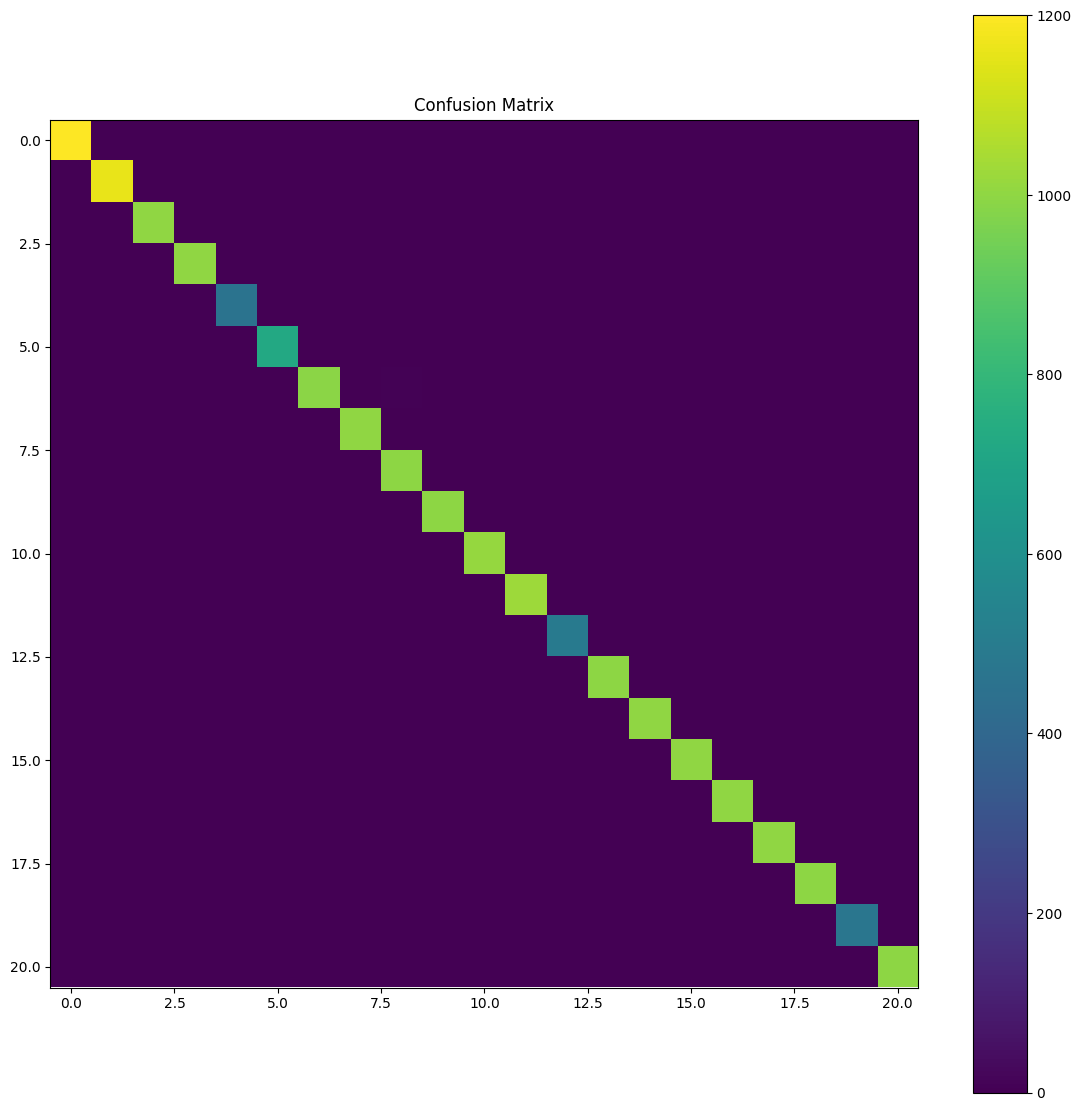

In [9]:
cm = confusion_matrix(

    all_labels,

    all_preds
)


plt.figure(
    figsize=(14,14)
)

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.show()

In [10]:
sample_images = 10


for i in range(sample_images):

    image, label = dataset[i]


    tensor = image.unsqueeze(0).to(
        DEVICE
    )


    with torch.no_grad():

        output = model(
            tensor
        )


        probs = torch.softmax(
            output,
            dim=1
        )


        top_probs, top_preds = torch.topk(
            probs,
            3
        )


    print()
    print(
        "Real:",
        CLASSES[label]
    )


    for j in range(3):

        pred_idx = top_preds[0][j].item()

        pred_conf = float(
            top_probs[0][j]
        )


        print(

            f"Top {j+1}:",

            CLASSES[pred_idx],

            f"{pred_conf:.4f}"
        )


Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: watermelon 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: watermelon 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: spaghetti_bolognese 0.0000
Top 3: watermelon 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: lemon 0.0000

Real: apple
Top 1: apple 0.9999
Top 2: mango 0.0001
Top 3: banana 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: watermelon 0.0000

Real: apple
Top 1: apple 0.9996
Top 2: mango 0.0003
Top 3: lemon 0.0001

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: spaghetti_bolognese 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: banana 0.0000

Real: apple
Top 1: apple 1.0000
Top 2: mango 0.0000
Top 3: banana 0.0000
